In [2]:
!pip install -U bitsandbytes accelerate

In [3]:
!pip install -q scikit-learn datasets wandb

In [4]:
import os

In [5]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
"""
==========================================================================
  Qwen2.5 ABSA — Instruction Fine-Tuning (Generative / Prompt-based)
  Target platform : Kaggle T4 x2  (single-GPU path with device_map)
  Author          : converted from Feature-Extraction baseline
==========================================================================
"""
 
import os, json, re, random, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import wandb
 
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F8F9FA",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.family":      "DejaVu Sans",
})
SAVEFIG_KWARGS = dict(dpi=150, bbox_inches="tight", facecolor="white")
print("Imports OK ✓")

Imports OK ✓


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# 0.  GLOBAL CONFIG
# ══════════════════════════════════════════════════════════════════════════
LABEL_COLUMNS = [
    "graphics", "matchmaking", "store & microtransactions",
    "technical_issue", "mechanics", "developer_support",
    "event", "community", "hero_design", "difficulty",
]
NUM_ASPECTS  = len(LABEL_COLUMNS)   # 10
NUM_CLASSES  = 3                    # 0=not_mentioned, 1=neutral_pos, 2=negative
TARGET_NAMES = ["not_mentioned", "neutral_pos", "negative"]
 
# Ánh xạ label string ↔ int
STR2INT = {n: i for i, n in enumerate(TARGET_NAMES)}   # {'not_mentioned':0, ...}
INT2STR = {i: n for i, n in enumerate(TARGET_NAMES)}   # {0:'not_mentioned', ...}
 
DATA_PATH  = "/kaggle/input/datasets/bebbequin/dataset/"
OUTPUT_DIR = "/kaggle/working/qwen_ift_absa"
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
 
MAX_LEN    = 400   # tổng chiều dài (prompt + JSON answer)
BATCH_SIZE = 16
NUM_EPOCHS = 5
SEED       = 42
 
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
 
def set_seed(s: int):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
 
set_seed(SEED)
 
print("CUDA:", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA: True
GPU : Tesla T4


In [ ]:
train_df = pd.read_csv(DATA_PATH + 'train.csv')
val_df = pd.read_csv(DATA_PATH + 'val.csv')
test_df = pd.read_csv(DATA_PATH + 'test.csv')
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 4152 | Val: 519 | Test: 519


In [9]:
df = pd.read_csv('/kaggle/input/datasets/bebbequin/qwen-preprocessed/qwen_preprocess.csv')[["review"] + LABEL_COLUMNS]

## EDA

### Phân bố nhãn theo từng aspect

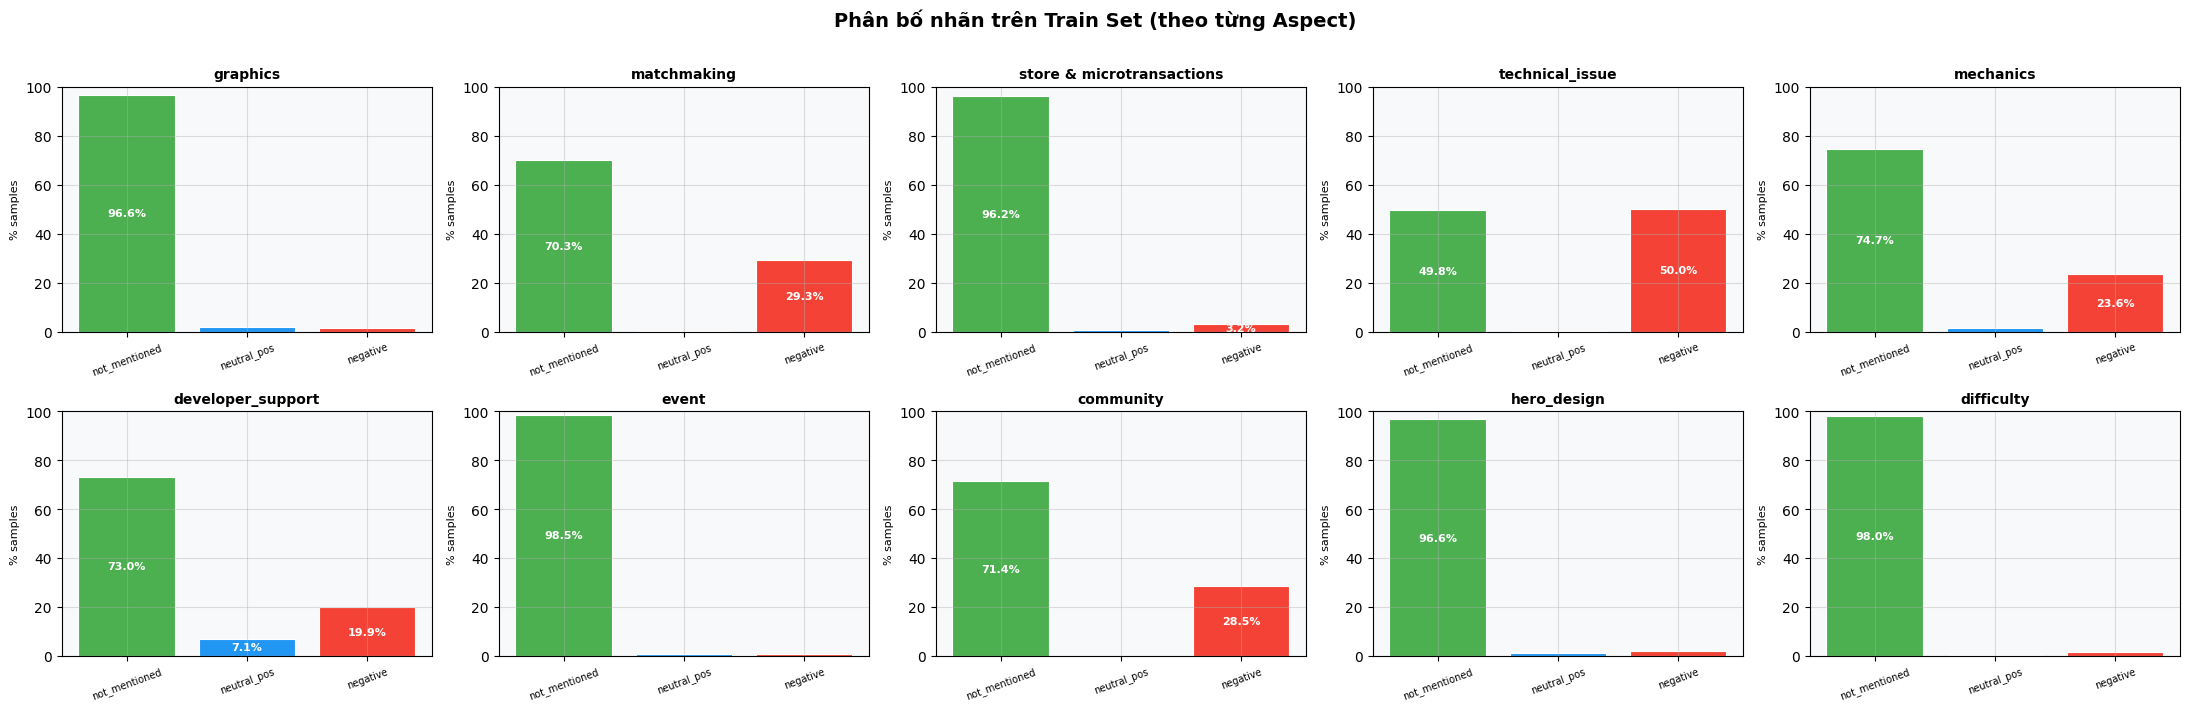

Saved: plot_01_label_distribution.png


In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(22, 7), sharey=False)
colors = ["#4CAF50", "#2196F3", "#F44336"]
 
for ax, col in zip(axes.flatten(), LABEL_COLUMNS):
    counts = train_df[col].value_counts().sort_index().reindex([0, 1, 2], fill_value=0)
    pcts   = counts / counts.sum() * 100
    bars   = ax.bar(TARGET_NAMES, pcts, color=colors, edgecolor="white", linewidth=0.8)
    for bar, pct in zip(bars, pcts):
        if pct > 3:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
                    f"{pct:.1f}%", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 100); ax.set_ylabel("% samples", fontsize=8)
    ax.tick_params(axis="x", rotation=20, labelsize=7)
 
plt.suptitle("Phân bố nhãn trên Train Set (theo từng Aspect)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_01_label_distribution.png", **SAVEFIG_KWARGS)
plt.show(); print("Saved: plot_01_label_distribution.png")

### Tỉ lệ split và phân bố nhãn giữa các tập train/val/test

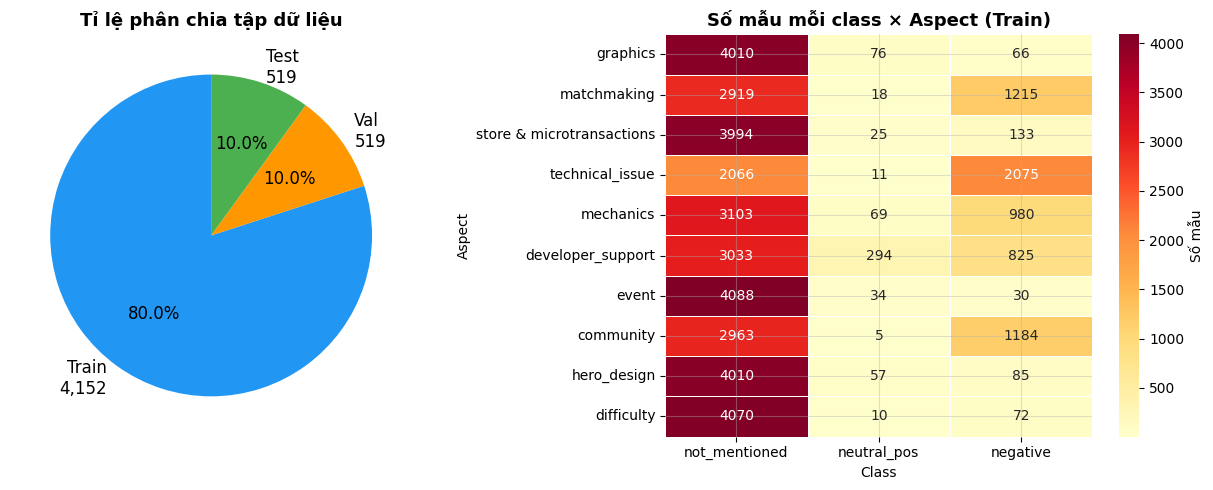

Saved: plot_02_data_overview.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sizes  = [len(train_df), len(val_df), len(test_df)]
labels = [f"Train\n{len(train_df):,}", f"Val\n{len(val_df):,}", f"Test\n{len(test_df):,}"]
ax1.pie(sizes, labels=labels, autopct="%1.1f%%",
        colors=["#2196F3", "#FF9800", "#4CAF50"],
        startangle=90, textprops={"fontsize": 12})
ax1.set_title("Tỉ lệ phân chia tập dữ liệu", fontsize=13, fontweight="bold")
 
imbalance = []
for col in LABEL_COLUMNS:
    counts = train_df[col].value_counts().sort_index().reindex([0, 1, 2], fill_value=0)
    imbalance.append(counts.values)
imbalance_df = pd.DataFrame(imbalance, index=LABEL_COLUMNS, columns=TARGET_NAMES)
sns.heatmap(imbalance_df, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax2, cbar_kws={"label": "Số mẫu"})
ax2.set_title("Số mẫu mỗi class × Aspect (Train)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Class"); ax2.set_ylabel("Aspect")
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_02_data_overview.png", **SAVEFIG_KWARGS)
plt.show(); print("Saved: plot_02_data_overview.png")

## Training resources

### Tokenizer và zero-shot prompting

In [ ]:
print("\nLoading tokenizer …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"   # causal LM cần padding bên phải
 
 
SYSTEM_PROMPT = (
    "Bạn là một hệ thống phân tích cảm xúc theo khía cạnh (ABSA) chuyên biệt. "
    "Nhiệm vụ của bạn là đọc bình luận về game và trả về KẾT QUẢ DUY NHẤT "
    "là một chuỗi JSON hợp lệ chứa đánh giá cho đúng 10 khía cạnh sau: "
    + ", ".join(LABEL_COLUMNS) + ". "
    "Mỗi giá trị BẮT BUỘC phải là một trong: "
    "'not_mentioned', 'neutral_pos', 'negative'. "
    "KHÔNG được thêm bất kỳ văn bản, giải thích hay markdown nào ngoài JSON."
)
 
 
def build_label_json(row: pd.Series) -> str:
    """Chuyển nhãn số thành chuỗi JSON cho assistant."""
    d = {col: INT2STR[int(row[col])] for col in LABEL_COLUMNS}
    return json.dumps(d, ensure_ascii=False)
 
 
def build_chat_messages(review: str, label_json: str | None = None) -> list[dict]:
    """
    Trả về danh sách messages theo chuẩn ChatML.
    Nếu label_json=None → chỉ build prompt (inference mode).
    """
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": f"Bình luận: {review}"},
    ]
    if label_json is not None:
        messages.append({"role": "assistant", "content": label_json})
    return messages
 


Loading tokenizer …


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Dataset

In [ ]:
class QwenPromptDataset(Dataset):
    """
    Tokenize toàn bộ hội thoại (system + user + assistant).
    labels = input_ids (causal LM loss).
    Phần system+user sẽ bị mask = -100 bởi DataCollatorForSeq2Seq.
    """
 
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 512):
        self.data       = df.reset_index(drop=True)
        self.tok        = tokenizer
        self.max_length = max_length
        # Pre-tokenize prompt-only template để biết độ dài phần prefix cần mask
        self._dummy_prefix_len = self._compute_prefix_len()
 
    def _compute_prefix_len(self) -> int:
        """Tính độ dài token của phần [system + user] (không có assistant)."""
        dummy_msgs = build_chat_messages(review="X", label_json=None)
        # Bỏ return_tensors="pt" để apply_chat_template trả về List[int] chuẩn
        prefix_ids = self.tok.apply_chat_template(
            dummy_msgs,
            tokenize=True,
            add_generation_prompt=True,
        )
        return len(prefix_ids)
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        row        = self.data.iloc[idx]
        review     = row["review"]
        label_json = build_label_json(row)
 
        # ── Tokenize full conversation ──
        full_msgs = build_chat_messages(review, label_json)
        full_res  = self.tok.apply_chat_template(
            full_msgs,
            tokenize=True,
            add_generation_prompt=False,
            return_tensors="pt",
        )

        full_ids = full_res["input_ids"].squeeze(0)  # Kích thước: [seq_len]
 
        # ── Tokenize prefix (system + user) để xác định vị trí mask ──
        prefix_msgs = build_chat_messages(review, label_json=None)
        prefix_res  = self.tok.apply_chat_template(
            prefix_msgs,
            tokenize=True,
            add_generation_prompt=True,   # thêm <|im_start|>assistant\n
            return_tensors="pt",
        )
        prefix_ids = prefix_res["input_ids"].squeeze(0)
        prefix_len = len(prefix_ids)
 
        if len(full_ids) > self.max_length:
            full_ids = full_ids[: self.max_length]
 
        labels = full_ids.clone()
        labels[:prefix_len] = -100  # mask system + user tokens
 
        return {
            "input_ids":      full_ids,
            "attention_mask": torch.ones_like(full_ids),
            "labels":         labels,
        }

In [14]:
train_dataset = QwenPromptDataset(train_df, tokenizer, MAX_LEN)
val_dataset   = QwenPromptDataset(val_df,   tokenizer, MAX_LEN)
test_dataset  = QwenPromptDataset(test_df,  tokenizer, MAX_LEN)
print(f"Datasets built — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
 
# Kiểm tra 1 mẫu
sample = train_dataset[0]
print("Sample keys    :", list(sample.keys()))
print("input_ids shape:", sample["input_ids"].shape)
print("labels shape   :", sample["labels"].shape)
non_masked = (sample["labels"] != -100).sum().item()
print(f"Non-masked tokens (assistant part): {non_masked}")

Datasets built — Train: 4152 | Val: 519 | Test: 519
Sample keys    : ['input_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([274])
labels shape   : torch.Size([274])
Non-masked tokens (assistant part): 85


In [ ]:
# DataCollatorForSeq2Seq: pad input_ids bằng pad_token_id,
#                          pad labels bằng -100 (không tính loss trên padding)
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=None,                      
    padding=True,
    pad_to_multiple_of=8,            
    label_pad_token_id=-100,
    return_tensors="pt",
)
print("DataCollatorForSeq2Seq ready ✓")

DataCollatorForSeq2Seq ready ✓


### Model backbone và QLoRA config

In [ ]:
print("\nLoading model with 4-bit quantization …")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
 
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True,
)
model = prepare_model_for_kbit_training(model)
 
# LoRA config
lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "v_proj", "k_proj", "o_proj",   # Attention
        "gate_proj", "up_proj", "down_proj",        # MLP
    ],
    bias="none",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()
print("Model ready ✓")
 
# Cập nhật data_collator với model thực
data_collator.model = model


Loading model with 4-bit quantization …


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
Model ready ✓


In [ ]:
FINAL_OUTPUT_DIR = f"{OUTPUT_DIR}/final_model"
os.makedirs(FINAL_OUTPUT_DIR, exist_ok=True)
 
total_steps   = (len(train_dataset) // (BATCH_SIZE * 2)) * NUM_EPOCHS
warmup_steps  = max(1, int(total_steps * 0.1))
 
training_args = TrainingArguments(
    output_dir=FINAL_OUTPUT_DIR,
 
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    gradient_checkpointing=True,
 
    fp16=True,
 
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  
    save_total_limit=3,

    logging_strategy="steps",
    logging_steps=20,
    logging_first_step=True,
    disable_tqdm=False,

    report_to="wandb",
    run_name="qwen_ift_absa_v1",
 
    remove_unused_columns=False,
    seed=SEED,
    dataloader_num_workers=2,
)
 
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [18]:
print("Trainer ready ✓")
print(f"  Epochs      : {NUM_EPOCHS}")
print(f"  Batch size  : {BATCH_SIZE} (×2 grad_accum = effective {BATCH_SIZE*2})")
print(f"  LR          : 2e-4")
print(f"  Total steps : {total_steps}")
print(f"  Warmup steps: {warmup_steps}")

Trainer ready ✓
  Epochs      : 5
  Batch size  : 16 (×2 grad_accum = effective 32)
  LR          : 2e-4
  Total steps : 645
  Warmup steps: 64


In [ ]:
# Check input length để ko bị OOM
for i in range(min(10, len(train_dataset))):
    sample = train_dataset[i]
    print(f"Sample {i} - input_ids length: {len(sample['input_ids'])}")

Sample 0 - input_ids length: 274
Sample 1 - input_ids length: 285
Sample 2 - input_ids length: 279
Sample 3 - input_ids length: 273
Sample 4 - input_ids length: 250
Sample 5 - input_ids length: 295
Sample 6 - input_ids length: 259
Sample 7 - input_ids length: 262
Sample 8 - input_ids length: 244
Sample 9 - input_ids length: 256


## Training

In [ ]:
wandb.init(project="game-review-absa", name="qwen_ift_absa_v1")
print("\nStarting training …")
trainer.train()
print("Training complete ✓")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: phiquyentran28 (phiquyentran28-uit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



Starting training …


Epoch,Training Loss,Validation Loss
1,0.019841,0.021021
2,0.015418,0.017352
3,0.010810,0.017423
4,0.005801,0.021287
5,0.002507,0.029122


Training complete ✓


- Có vẻ hơi overfitting

### Predict and save model

In [ ]:
def predict_absa_prompt(
    text: str,
    model,
    tokenizer,
    max_new_tokens: int = 128,
    device: str = "cuda",
) -> list[int]:
    """
    Sinh nhãn ABSA cho một review.
    """
    model.eval()
    messages = build_chat_messages(text, label_json=None)

    tokenized_outputs = tokenizer.apply_chat_template(
        messages,  # fix msgs 
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    )

    # Trích xuất tensor input_ids và đưa lên đúng device (GPU)
    if isinstance(tokenized_outputs, dict) or hasattr(
        tokenized_outputs, "data"
    ):
        input_ids = tokenized_outputs["input_ids"].to(device)
    else:
        input_ids = tokenized_outputs.to(device)
 
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,  
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
 
    # Chỉ lấy phần token mới (assistant's answer)
    new_tokens = output_ids[0][input_ids.shape[1] :]
    raw_text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
 
    # ── Parse JSON ──
    try:
        # Loại bỏ markdown code fence nếu có
        raw_text = re.sub(r"```(?:json)?", "", raw_text).strip().rstrip("`").strip()
        pred_dict = json.loads(raw_text)
    except (json.JSONDecodeError, ValueError):
        match = re.search(r"\{.*\}", raw_text, re.DOTALL)
        if match:
            try:
                pred_dict = json.loads(match.group())
            except Exception:
                pred_dict = {}
        else:
            pred_dict = {}
 
    # ── Ánh xạ ngược về số ──
    return [STR2INT.get(pred_dict.get(col, "not_mentioned"), 0) for col in LABEL_COLUMNS]
 
 
def batch_predict(
    reviews: list[str],
    model,
    tokenizer,
    batch_size: int = 8,
    device: str = "cuda",
    verbose: bool = True,
) -> np.ndarray:
    """
    Chạy inference trên danh sách reviews.
    Trả về np.ndarray shape (N, NUM_ASPECTS) với các giá trị trong 0,1,2.
    """
    all_preds = []
    for i in range(0, len(reviews), batch_size):
        batch = reviews[i: i + batch_size]
        for text in batch:
            preds = predict_absa_prompt(text, model, tokenizer, device=device)
            all_preds.append(preds)
        if verbose:
            print(f"  Inference: {min(i + batch_size, len(reviews))}/{len(reviews)}", end="\r")
    if verbose:
        print()
    return np.array(all_preds, dtype=np.int64)

In [ ]:
def save_predictions_csv(
    split_df: pd.DataFrame,
    preds: np.ndarray,
    labels: np.ndarray,
    save_path: str,
) -> pd.DataFrame:
    """
    Tạo DataFrame với cấu trúc:
      review | graphics_true | graphics_pred | ... | difficulty_true | difficulty_pred | n_errors
    Lưu ra file CSV và trả về DataFrame.
 
    Parameters
    ----------
    split_df  : DataFrame gốc chứa cột 'review' và các cột nhãn
    preds     : np.ndarray shape (N, 10) - nhãn dự đoán (int)
    labels    : np.ndarray shape (N, 10) -  nhãn thực tế (int)
    save_path : output path
    """
    rows = []
    for idx in range(len(split_df)):
        row = {"review": split_df.iloc[idx]["review"]}
        n_errors = 0
        for j, col in enumerate(LABEL_COLUMNS):
            t = int(labels[idx, j])
            p = int(preds[idx, j])
            row[f"{col}_true"] = t
            row[f"{col}_pred"] = p
            if t != p:
                n_errors += 1
        row["n_errors"] = n_errors
        rows.append(row)
 
    out_df = pd.DataFrame(rows)
    out_df.to_csv(save_path, index=False, encoding="utf-8-sig")
    print(f"  Saved predictions → {save_path}  ({len(out_df)} rows)")
    return out_df

In [23]:
try:
    local_save_path = FINAL_OUTPUT_DIR
except NameError:
    local_save_path = "./qwen_absa_results/final_model"

print(f"=== TIẾN HÀNH LƯU MÔ HÌNH CỤC BỘ ===")
print(f"Thư mục lưu trữ: {local_save_path}\n")
try:
    # Nếu đối tượng 'trainer' đang tồn tại trong bộ nhớ
    if "trainer" in globals():
        print("[1/3] Đang lưu mô hình thông qua Trainer...")
        trainer.save_model(local_save_path)
    else:
        # Nếu chỉ có đối tượng 'model' và 'tokenizer' riêng lẻ
        print("[1/3] Không tìm thấy Trainer. Tiến hành lưu trực tiếp Model và Tokenizer...")
        model.save_pretrained(local_save_path)
        
    if "tokenizer" in globals():
        tokenizer.save_pretrained(local_save_path)
        print(" -> Lưu Tokenizer thành công!")
    
    print(f" -> Đã lưu thành công mô hình cục bộ tại: {local_save_path}\n")

except Exception as e:
    print(f" Lỗi khi lưu mô hình cục bộ: {str(e)}")

=== TIẾN HÀNH LƯU MÔ HÌNH CỤC BỘ ===
Thư mục lưu trữ: /kaggle/working/qwen_ift_absa/final_model

[1/3] Đang lưu mô hình thông qua Trainer...
 -> Lưu Tokenizer thành công!
 -> Đã lưu thành công mô hình cục bộ tại: /kaggle/working/qwen_ift_absa/final_model



### Hugging Face push

In [24]:
import os
import torch
from huggingface_hub import HfApi

In [25]:
HF_USERNAME = "viegosequel"
REPO_NAME = "qwen-game-review-absa-instruct_v1"
REPO_ID = f"{HF_USERNAME}/{REPO_NAME}"

In [26]:
FINAL_OUTPUT_DIR = "/kaggle/working/save_model/"
os.makedirs(FINAL_OUTPUT_DIR, exist_ok=True)

In [32]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("hugging_face_key")

In [33]:
HF_TOKEN = secret_value_0

In [34]:
from huggingface_hub import HfApi, login

In [36]:
try:
    if 'local_save_path' in globals():
        source_folder = local_save_path
    elif 'FINAL_OUTPUT_DIR' in globals():
        source_folder = FINAL_OUTPUT_DIR
    else:
        source_folder = "./qwen_absa_results/final_model"
except NameError:
    source_folder = "./qwen_absa_results/final_model"

print("=== TIẾN HÀNH PUSH LORA ADAPTERS BẰNG HF_HUB API ===")
print(f" -> Thư mục nguồn cục bộ: {source_folder}")

try:
    print(" -> Đang tiến hành xác thực tài khoản...")
    login(token=HF_TOKEN, add_to_git_credential=False)
    
    api = HfApi()
    user_info = api.whoami()
    print(f" ✓ Xác thực thành công tài khoản: {user_info['name']}")

    # tạo repo
    print(f" -> Kiểm tra/Tạo repository: https://huggingface.co/{REPO_ID}")
    api.create_repo(repo_id=REPO_ID, private=False, exist_ok=True)

    print(" -> Đang upload các file LoRA Adapter lên Hugging Face Cloud...")
    print("    (Quá trình này mất khoảng vài chục giây tùy thuộc vào kích thước file...)")
    
    api.upload_folder(
        folder_path=source_folder,
        repo_id=REPO_ID,
        repo_type="model",
        commit_message="Huấn luyện hoàn tất: Đẩy QLoRA adapter đồ án ABSA từ cục bộ lên"
    )

    print("\n" + "="*40)
    print(" ✓ HOÀN THÀNH!")
    print(f" -> Mô hình và các cấu hình của bạn đã có tại: https://huggingface.co/{REPO_ID}")
    print("="*40)

except Exception as e:
    print(f"\n Thất bại! Gặp lỗi trong quá trình upload: {str(e)}")

=== TIẾN HÀNH PUSH LORA ADAPTERS BẰNG HF_HUB API ===
 -> Thư mục nguồn cục bộ: /kaggle/working/qwen_ift_absa/final_model
 -> Đang tiến hành xác thực tài khoản...
 ✓ Xác thực thành công tài khoản: viegosequel
 -> Kiểm tra/Tạo repository: https://huggingface.co/viegosequel/qwen-game-review-absa-instruct_v1
 -> Đang upload các file LoRA Adapter lên Hugging Face Cloud...
    (Quá trình này mất khoảng vài chục giây tùy thuộc vào kích thước file...)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


 ✓ HOÀN THÀNH!
 -> Mô hình và các cấu hình của bạn đã có tại: https://huggingface.co/viegosequel/qwen-game-review-absa-instruct_v1


## Phân tích lỗi

In [ ]:
print("\n>>> Evaluating on VALIDATION set …")
 
val_reviews = val_df["review"].tolist()
val_labels  = val_df[LABEL_COLUMNS].values.astype(np.int64)
val_preds   = batch_predict(val_reviews, model, tokenizer, batch_size=16)
 
val_f1s = [
    f1_score(val_labels[:, i], val_preds[:, i], average="macro", zero_division=0)
    for i in range(NUM_ASPECTS)
]
print(f"\nVal macro_f1_mean : {np.mean(val_f1s):.4f}")
for col, f1 in zip(LABEL_COLUMNS, val_f1s):
    print(f"  {col:<35} F1={f1:.4f}")
 
# ── Xuất CSV Validation ──
val_pred_df = save_predictions_csv(
    split_df  = val_df.reset_index(drop=True),
    preds     = val_preds,
    labels    = val_labels,
    save_path = f"{OUTPUT_DIR}/val_predictions.csv",
)

# Kiểm tra nhanh
print("\nVal predictions CSV preview:")
print(val_pred_df.head(3).to_string(index=False))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



>>> Evaluating on VALIDATION set …
  Inference: 519/519

Val macro_f1_mean : 0.6629
  graphics                            F1=0.7664
  matchmaking                         F1=0.6138
  store & microtransactions           F1=0.5970
  technical_issue                     F1=0.6184
  mechanics                           F1=0.5614
  developer_support                   F1=0.7383
  event                               F1=0.7539
  community                           F1=0.6184
  hero_design                         F1=0.7962
  difficulty                          F1=0.5656
  Saved predictions → /kaggle/working/qwen_ift_absa/val_predictions.csv  (519 rows)

Val predictions CSV preview:
                                                                                                         review  graphics_true  graphics_pred  matchmaking_true  matchmaking_pred  store & microtransactions_true  store & microtransactions_pred  technical_issue_true  technical_issue_pred  mechanics_true  mechanics_pred  de

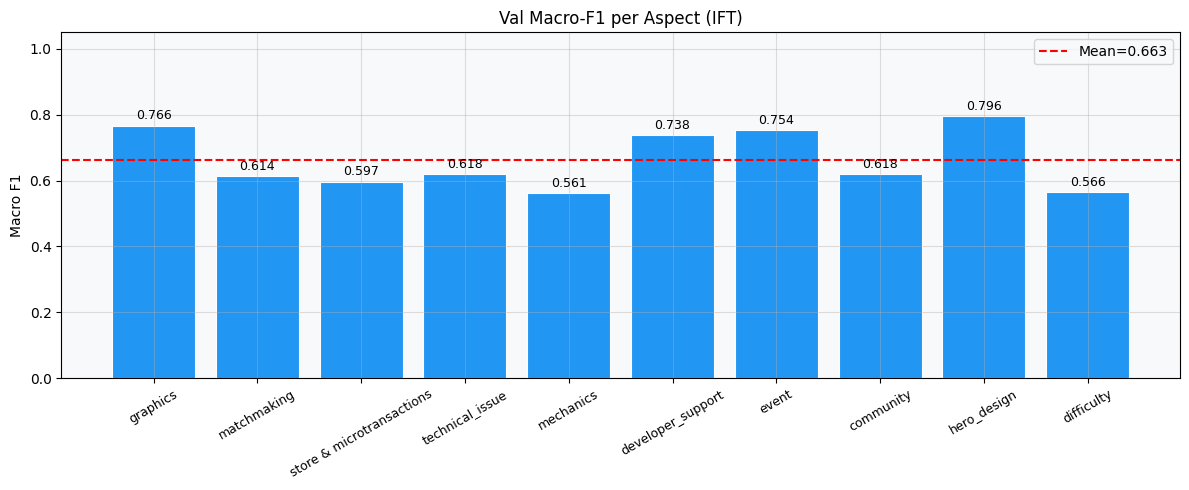

Saved: plot_03_val_f1_per_aspect.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(LABEL_COLUMNS, val_f1s, color="#2196F3", edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, val_f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(np.mean(val_f1s), color="red", linestyle="--",
           label=f"Mean={np.mean(val_f1s):.3f}")
ax.set_ylim(0, 1.05); ax.set_ylabel("Macro F1")
ax.set_title("Val Macro-F1 per Aspect (IFT)")
ax.tick_params(axis="x", rotation=30, labelsize=9); ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_03_val_f1_per_aspect.png", **SAVEFIG_KWARGS)
plt.show(); print("Saved: plot_03_val_f1_per_aspect.png")

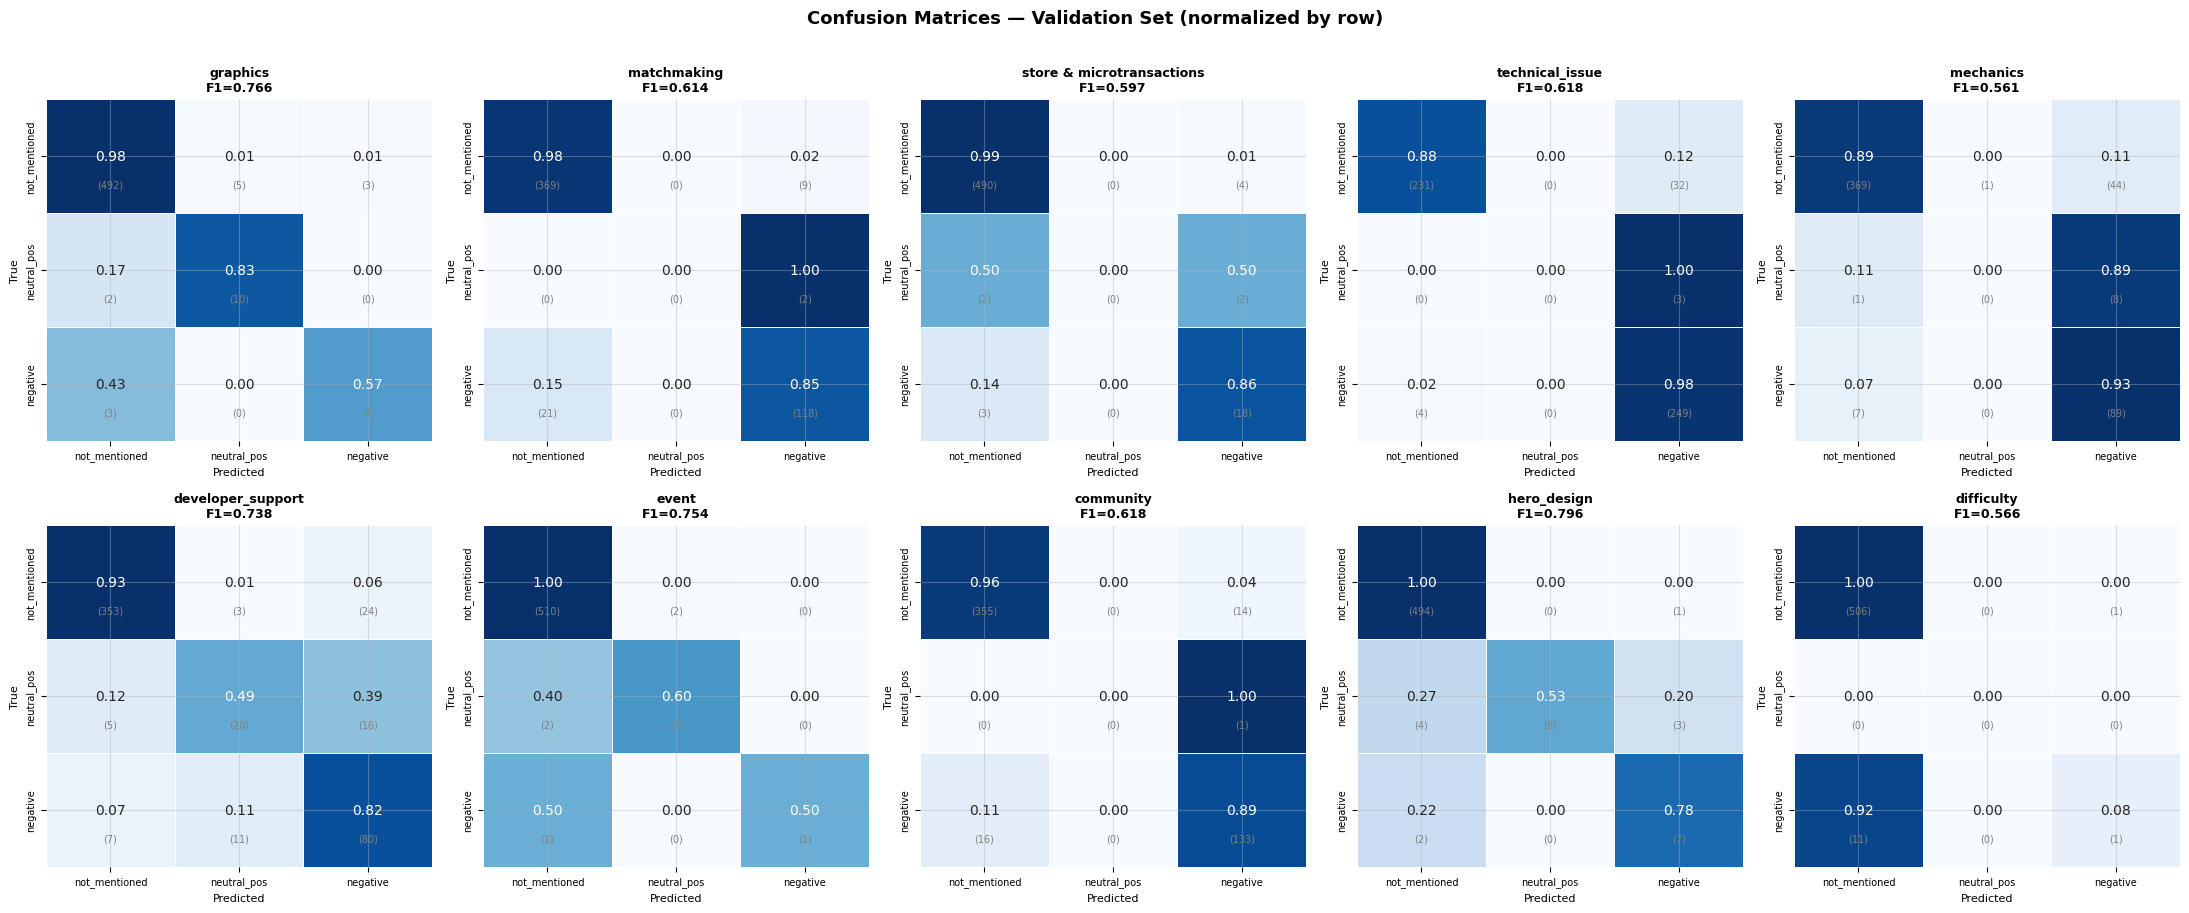

Saved: plot_04_val_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, col, i in zip(axes.flatten(), LABEL_COLUMNS, range(NUM_ASPECTS)):
    cm      = confusion_matrix(val_labels[:, i], val_preds[:, i], labels=[0, 1, 2])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                cbar=False, linewidths=0.5)
    for r in range(3):
        for c_ in range(3):
            ax.text(c_ + 0.5, r + 0.75, f"({cm[r, c_]})",
                    ha="center", va="center", fontsize=7, color="gray")
    ax.set_title(f"{col}\nF1={val_f1s[i]:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("True", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
plt.suptitle("Confusion Matrices — Validation Set (normalized by row)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_04_val_confusion_matrices.png", **SAVEFIG_KWARGS)
plt.show(); print("Saved: plot_04_val_confusion_matrices.png")

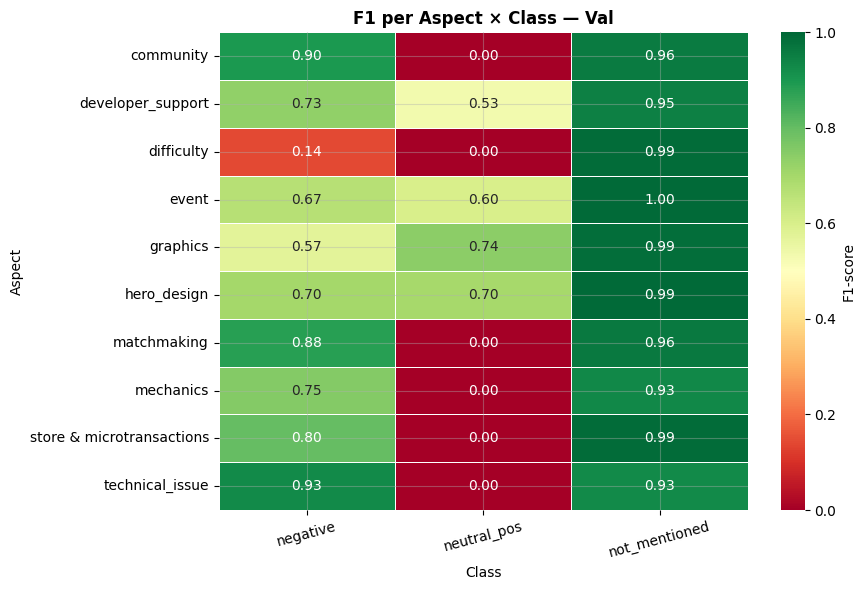

Saved: plot_05_val_f1_heatmap.png


In [ ]:
report_rows = []
for i, col in enumerate(LABEL_COLUMNS):
    rep = classification_report(
        val_labels[:, i], val_preds[:, i],
        labels=[0, 1, 2], target_names=TARGET_NAMES,
        output_dict=True, zero_division=0,
    )
    for cls in TARGET_NAMES:
        report_rows.append({
            "aspect": col, "class": cls,
            "f1": rep[cls]["f1-score"],
        })
rep_df  = pd.DataFrame(report_rows)
pivot   = rep_df.pivot_table(index="aspect", columns="class", values="f1")
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={"label": "F1-score"})
ax.set_title("F1 per Aspect × Class — Val", fontsize=12, fontweight="bold")
ax.set_xlabel("Class"); ax.set_ylabel("Aspect")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_05_val_f1_heatmap.png", **SAVEFIG_KWARGS)
plt.show(); print("Saved: plot_05_val_f1_heatmap.png")
 

In [ ]:
print("\n>>> Error Analysis on Val Set …")
error_df = val_pred_df[val_pred_df["n_errors"] > 0].copy()
# Tạo cột error_detail cho tiện đọc
def make_error_detail(row):
    d = {}
    for col in LABEL_COLUMNS:
        t, p = row[f"{col}_true"], row[f"{col}_pred"]
        if t != p:
            d[col] = f"{t}→{p}"
    return str(d)
 
error_df["error_detail"] = error_df.apply(make_error_detail, axis=1)
error_df = error_df.sort_values("n_errors", ascending=False)
 
print(f"  Mẫu bị lỗi ≥1 aspect  : {len(error_df)} / {len(val_df)}")
print(f"  Mẫu bị lỗi ≥3 aspects : {(error_df['n_errors'] >= 3).sum()}")
error_df[["review", "n_errors", "error_detail"]].to_csv(
    f"{OUTPUT_DIR}/val_error_analysis.csv", index=False, encoding="utf-8-sig"
)
print("  Saved: val_error_analysis.csv")
print("\nTop-10 mẫu lỗi nhiều nhất:")
print(error_df.head(10)[["review", "n_errors", "error_detail"]].to_string(index=False))


>>> Error Analysis on Val Set …
  Mẫu bị lỗi ≥1 aspect  : 195 / 519
  Mẫu bị lỗi ≥3 aspects : 14
  Saved: val_error_analysis.csv

Top-10 mẫu lỗi nhiều nhất:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      review  n_errors                                                                                              error_detail
                                                                                                                                                                                                                                                         

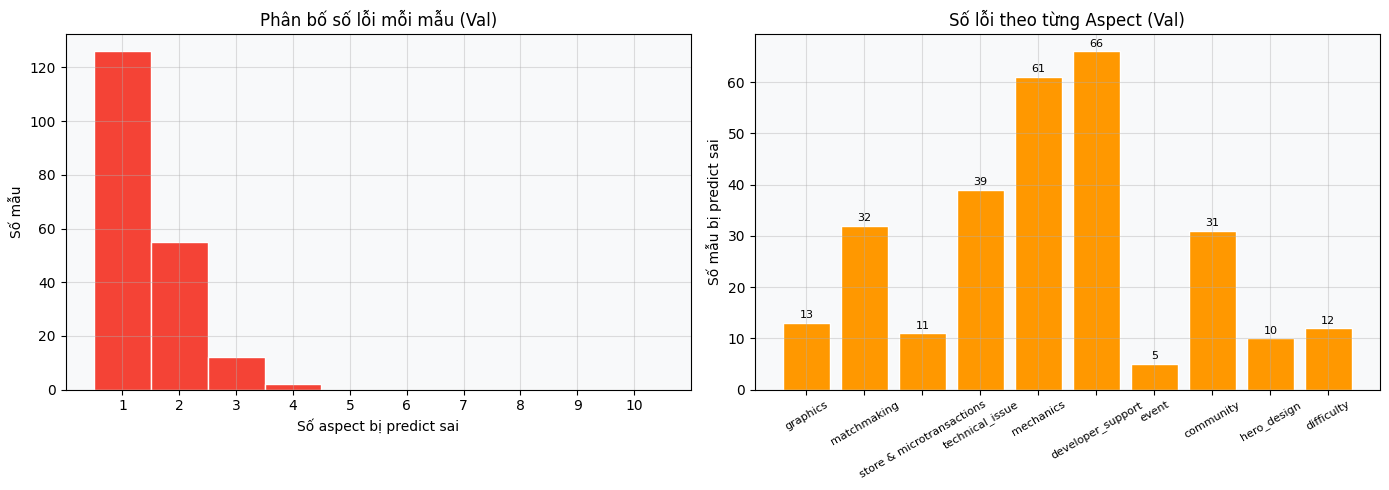

Saved: plot_06_val_error_distribution.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(error_df["n_errors"], bins=range(1, NUM_ASPECTS + 2),
         color="#F44336", edgecolor="white", align="left")
ax1.set_xlabel("Số aspect bị predict sai"); ax1.set_ylabel("Số mẫu")
ax1.set_title("Phân bố số lỗi mỗi mẫu (Val)")
ax1.set_xticks(range(1, NUM_ASPECTS + 1))
 
err_per_aspect = [int(np.sum(val_labels[:, i] != val_preds[:, i])) for i in range(NUM_ASPECTS)]
ax2.bar(LABEL_COLUMNS, err_per_aspect, color="#FF9800", edgecolor="white")
ax2.set_ylabel("Số mẫu bị predict sai")
ax2.set_title("Số lỗi theo từng Aspect (Val)")
ax2.tick_params(axis="x", rotation=30, labelsize=8)
for bar, v in zip(ax2.patches, err_per_aspect):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_06_val_error_distribution.png", **SAVEFIG_KWARGS)
plt.show(); print("Saved: plot_06_val_error_distribution.png")

In [ ]:
print("\n>>> Evaluating on TEST set …")
 
test_reviews = test_df["review"].tolist()
test_labels  = test_df[LABEL_COLUMNS].values.astype(np.int64)
test_preds   = batch_predict(test_reviews, model, tokenizer, batch_size=16)
 
test_f1s = [
    f1_score(test_labels[:, i], test_preds[:, i], average="macro", zero_division=0)
    for i in range(NUM_ASPECTS)
]
print(f"\nTest macro_f1_mean : {np.mean(test_f1s):.4f}")
for col, f1 in zip(LABEL_COLUMNS, test_f1s):
    print(f"  {col:<35} F1={f1:.4f}")
 
# ── Xuất CSV Test ──
test_pred_df = save_predictions_csv(
    split_df  = test_df.reset_index(drop=True),
    preds     = test_preds,
    labels    = test_labels,
    save_path = f"{OUTPUT_DIR}/test_predictions.csv",
)
 
print("\nTest predictions CSV preview:")
print(test_pred_df.head(3).to_string(index=False))


>>> Evaluating on TEST set …
  Inference: 519/519

Test macro_f1_mean : 0.6375
  graphics                            F1=0.6210
  matchmaking                         F1=0.6106
  store & microtransactions           F1=0.4787
  technical_issue                     F1=0.9446
  mechanics                           F1=0.6256
  developer_support                   F1=0.7332
  event                               F1=0.5910
  community                           F1=0.6314
  hero_design                         F1=0.6422
  difficulty                          F1=0.4964
  Saved predictions → /kaggle/working/qwen_ift_absa/test_predictions.csv  (519 rows)

Test predictions CSV preview:
                                                                                                                                                                                                                                                                                                                                    

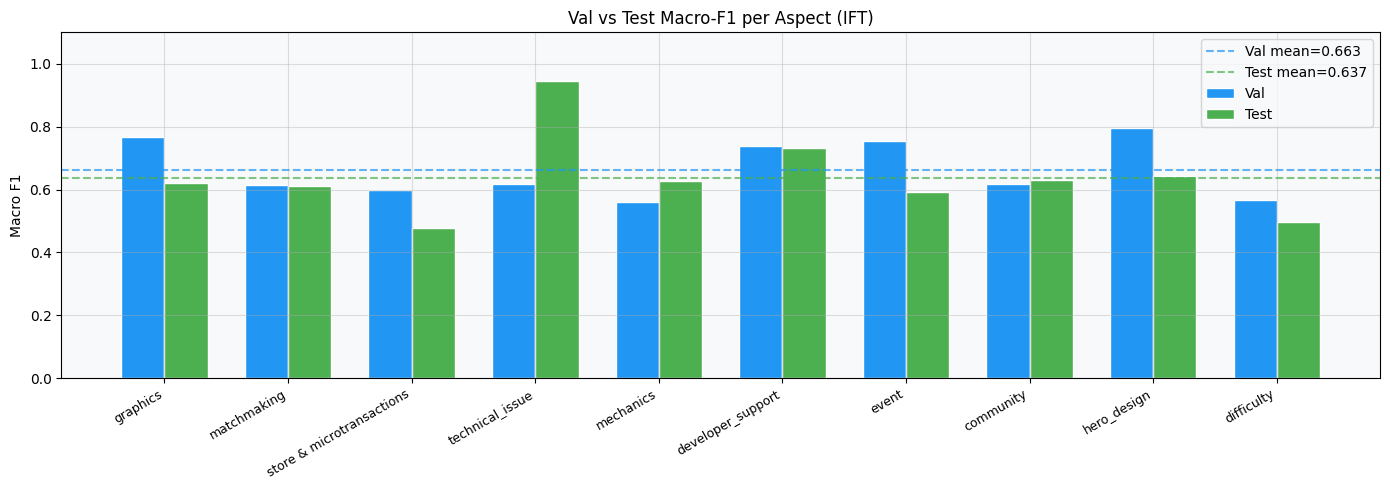

Saved: plot_07_val_vs_test_f1.png


In [44]:
x     = np.arange(NUM_ASPECTS)
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - width / 2, val_f1s,  width, label="Val",  color="#2196F3", edgecolor="white")
b2 = ax.bar(x + width / 2, test_f1s, width, label="Test", color="#4CAF50", edgecolor="white")
ax.axhline(np.mean(val_f1s),  color="#2196F3", linestyle="--", alpha=0.7,
           label=f"Val mean={np.mean(val_f1s):.3f}")
ax.axhline(np.mean(test_f1s), color="#4CAF50", linestyle="--", alpha=0.7,
           label=f"Test mean={np.mean(test_f1s):.3f}")
ax.set_xticks(x)
ax.set_xticklabels(LABEL_COLUMNS, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel("Macro F1")
ax.set_title("Val vs Test Macro-F1 per Aspect (IFT)"); ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_07_val_vs_test_f1.png", **SAVEFIG_KWARGS)
plt.show(); print("Saved: plot_07_val_vs_test_f1.png")

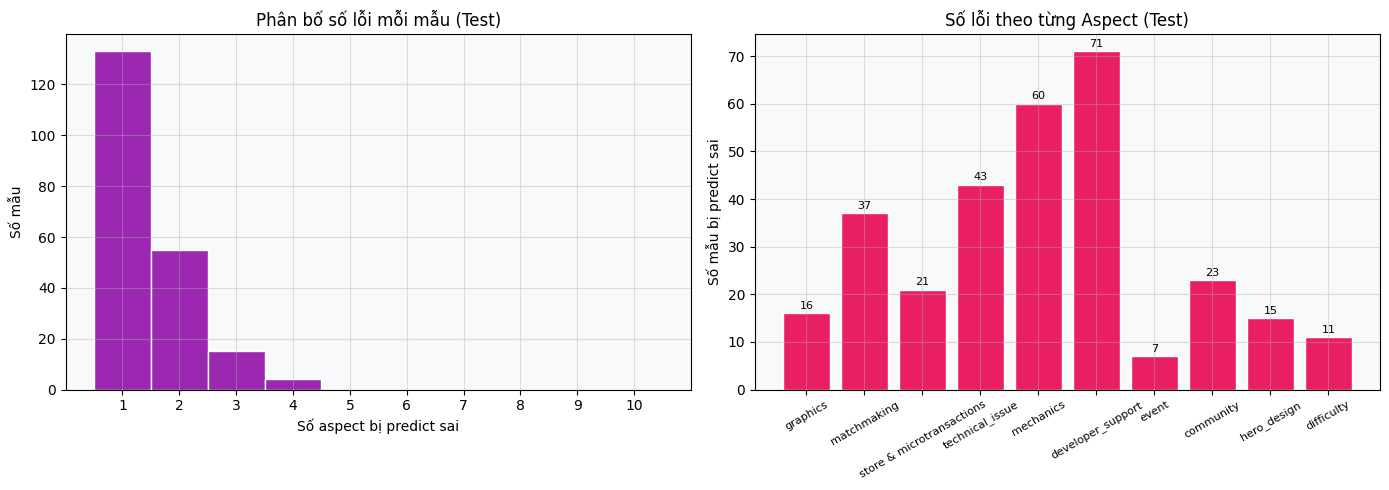

Saved: plot_08_test_error_distribution.png

Test error analysis: 207 / 519 mẫu bị lỗi ≥1 aspect
Saved: test_error_analysis.csv


In [45]:
test_error_df = test_pred_df[test_pred_df["n_errors"] > 0].copy()
test_error_df["error_detail"] = test_error_df.apply(make_error_detail, axis=1)
test_error_df = test_error_df.sort_values("n_errors", ascending=False)
test_error_df[["review", "n_errors", "error_detail"]].to_csv(
    f"{OUTPUT_DIR}/test_error_analysis.csv", index=False, encoding="utf-8-sig"
)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(test_error_df["n_errors"], bins=range(1, NUM_ASPECTS + 2),
         color="#9C27B0", edgecolor="white", align="left")
ax1.set_xlabel("Số aspect bị predict sai"); ax1.set_ylabel("Số mẫu")
ax1.set_title("Phân bố số lỗi mỗi mẫu (Test)")
ax1.set_xticks(range(1, NUM_ASPECTS + 1))
 
err_per_aspect_test = [int(np.sum(test_labels[:, i] != test_preds[:, i])) for i in range(NUM_ASPECTS)]
ax2.bar(LABEL_COLUMNS, err_per_aspect_test, color="#E91E63", edgecolor="white")
ax2.set_ylabel("Số mẫu bị predict sai")
ax2.set_title("Số lỗi theo từng Aspect (Test)")
ax2.tick_params(axis="x", rotation=30, labelsize=8)
for bar, v in zip(ax2.patches, err_per_aspect_test):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_08_test_error_distribution.png", **SAVEFIG_KWARGS)
plt.show(); print("Saved: plot_08_test_error_distribution.png")
 
print(f"\nTest error analysis: {len(test_error_df)} / {len(test_df)} mẫu bị lỗi ≥1 aspect")
print(f"Saved: test_error_analysis.csv")

In [46]:
all_metrics = {
    "model":  MODEL_NAME,
    "method": "Instruction Fine-Tuning (Generative)",
    "val": {
        "macro_f1_mean": float(np.mean(val_f1s)),
        "per_aspect": {col: float(f1) for col, f1 in zip(LABEL_COLUMNS, val_f1s)},
    },
    "test": {
        "macro_f1_mean": float(np.mean(test_f1s)),
        "per_aspect": {col: float(f1) for col, f1 in zip(LABEL_COLUMNS, test_f1s)},
    },
    "hyperparams": {
        "learning_rate":              2e-4,
        "batch_size":                 BATCH_SIZE,
        "gradient_accumulation_steps": 2,
        "num_epochs":                 NUM_EPOCHS,
        "weight_decay":               0.01,
        "lora_r":                     16,
        "lora_alpha":                 32,
        "lora_dropout":               0.05,
        "max_len":                    MAX_LEN,
    },
}
with open(f"{OUTPUT_DIR}/all_metrics.json", "w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2, ensure_ascii=False)
print("\nAll metrics saved ✓")


All metrics saved ✓


In [ ]:
print("\n>>> Saving model artifacts …")
model.save_pretrained(f"{OUTPUT_DIR}/lora_weights")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/tokenizer")
print(f"Artifacts saved to {OUTPUT_DIR} ✓")
 
print(f"\n{'='*60}")
print(f"SUMMARY  (Instruction Fine-Tuning)")
print(f"  Val  macro_f1_mean : {np.mean(val_f1s):.4f}")
print(f"  Test macro_f1_mean : {np.mean(test_f1s):.4f}")
print(f"\nOutput files:")
print(f"  {OUTPUT_DIR}/val_predictions.csv")
print(f"  {OUTPUT_DIR}/test_predictions.csv")
print(f"  {OUTPUT_DIR}/val_error_analysis.csv")
print(f"  {OUTPUT_DIR}/test_error_analysis.csv")
print(f"  {OUTPUT_DIR}/all_metrics.json")
print(f"{'='*60}")
 
wandb.finish()


>>> Saving model artifacts …
Artifacts saved to /kaggle/working/qwen_ift_absa ✓

SUMMARY  (Instruction Fine-Tuning)
  Val  macro_f1_mean : 0.6629
  Test macro_f1_mean : 0.6375

Output files:
  /kaggle/working/qwen_ift_absa/val_predictions.csv
  /kaggle/working/qwen_ift_absa/test_predictions.csv
  /kaggle/working/qwen_ift_absa/val_error_analysis.csv
  /kaggle/working/qwen_ift_absa/test_error_analysis.csv
  /kaggle/working/qwen_ift_absa/all_metrics.json


eval/loss,▃▁▁▃█
eval/runtime,▄▅█▁▄
eval/samples_per_second,▅▄▁█▅
eval/steps_per_second,▅▄▁█▅
train/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇████
train/global_step,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,█▂▂▂▁▂▁▁▁▁▂▁▁▁▁▁▂▁▂▂▂▁▁▂▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▅█████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
train/loss,█▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,0.02912
eval/runtime,91.2982
